#### Question 1 ####

Grâce à la base de données XCOM du NIST (http://physics.nist.gov/PhysRefData/Xcom/html/xcom1.html), le l'atténuation total pour 60 keV dans l'eau est de 0.2059 $cm^2/g$ ce qui donne pour densité de 1 g / $cm^3$ un $\mu$ de 0.2059/cm.

In [9]:
import numpy as np

mu = 0.2059 #/cm
I_0 = 60 #keV
x_5 = 5 #cm
x_20 = 20 #cm

def ration_output_input_intensity(x):
    return np.e**(-mu*x)

print(f'Fraction signal après 5 cm: {ration_output_input_intensity(x_5):.5f}')
print(f'Fraction signal après 20 cm: {ration_output_input_intensity(x_20):.5f}')

Fraction signal après 5 cm: 0.35719
Fraction signal après 20 cm: 0.01628


#### Question 2 ####

Pour répondre à cette question, la méthode 'laminogram()' du fichier reconstruction.py a été complété de la manière suivante:

In [ ]:
## reconstruire une image TDM en mode retroprojection
def laminogram():
    
    [nbprj, angles, sinogram] = readInput()

    # initialiser une image reconstruite
    image = np.zeros((geo.nbvox, geo.nbvox))

    # "etaler" les projections sur l'image
    # ceci sera fait de façon "voxel-driven"
    # pour chaque voxel, trouver la contribution du signal reçu
    # voxel‑driven laminogram
    # paramètres du détecteur
    L = geo.nbpix * geo.voxsize          # largeur physique du détecteur
    tmin = -L/2                           # début du détecteur
    dt = L / geo.nbpix                    # taille d’un pixel détecteur

    for j in range(geo.nbvox):            # boucle colonnes
        print(f"working on image column: {j+1}/{geo.nbvox}")
        x =  (j - geo.nbvox/2 + 0.5) * geo.voxsize   # coordonnée x du voxel

        for i in range(geo.nbvox):        # boucle lignes
            y = (i - geo.nbvox/2 + 0.5) * geo.voxsize   # coordonnée y du voxel
            total = 0.0                   # accumulation des contributions

            for a, th in enumerate(angles):           # boucle angles
                s = x*np.cos(th) + y*np.sin(th)       # projection du voxel sur le détecteur
                k = int(round((s - tmin) / dt))       # conversion en index détecteur

                if 0 <= k < geo.nbpix:                # si dans les bornes
                    total += sinogram[a, k]           # ajouter la valeur du sinogramme

            image[i, j] = total           # assigner la valeur finale du voxel
            

    image = np.fliplr(image) # mettre l'image à l'endroit
    util.saveImage(image, "laminogram2_192_04_image_droite")

: 

Ce code une fois roullé a permis de trouver le code du fichier sinogram-password.txt$$ \\ $$
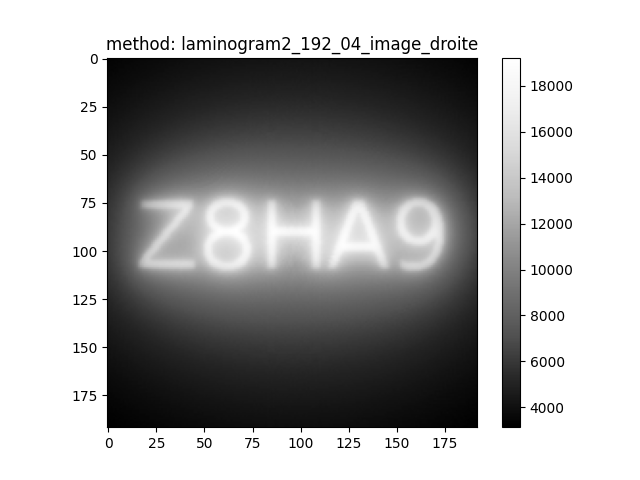$$ \\ $$

Code: Z8HA9

Maintenant, il est possible de trouver le laminograme-patient et de le comparer avec celui du CHU: $$ \\ $$
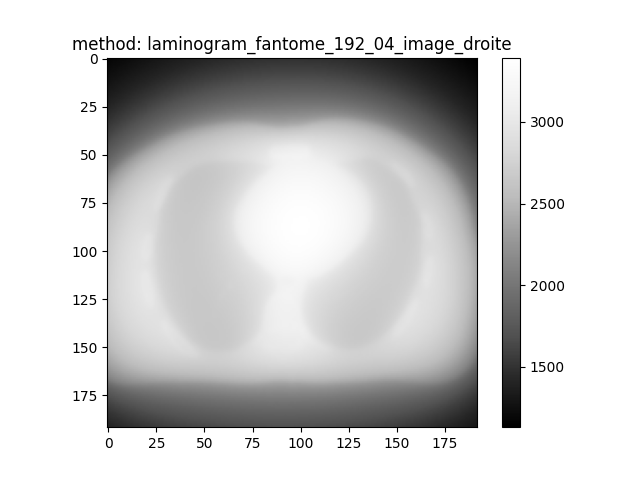 
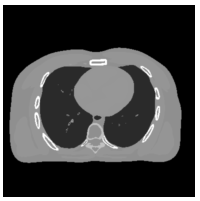 $$ \\ $$

Il est observable que le laminograme est beaucoup plus flou que celui de référence, en terme de fréquence, il semble y avoir uniquement les basse fréquence,donc des transition lente sur l'image et peux de hautes fréquences, des lignes bien distinctes.





#### Question 3 ####

#### Question 4 ####

#### Question 5 ####

#### Question 6 ####

#### Question 7 ####

#### Question 8 ####

#### Question 9 ####

#### Question 10 ####